Dataset Loaded
Samples: 10000
Total Features: 15

Baseline AUC (All Features): 0.9486

Using 2/3 Rule → Selecting top 10 features out of 15
AUC after retraining (2/3 features): 0.9431

AUC-Based Permutation Importance Ranking
   rank           feature  auc_importance_mean  auc_importance_std
0     1        popularity             0.093735            0.002964
1     2      acousticness             0.048356            0.002127
2     3      danceability             0.040355            0.001858
3     4  instrumentalness             0.031710            0.001726
4     5       speechiness             0.023644            0.000903
5     6            energy             0.017387            0.000303
6     7          loudness             0.016291            0.000891
7     8       duration_ms             0.014339            0.000326
8     9              mode             0.004883            0.000618
9    10          explicit             0.003335            0.000098





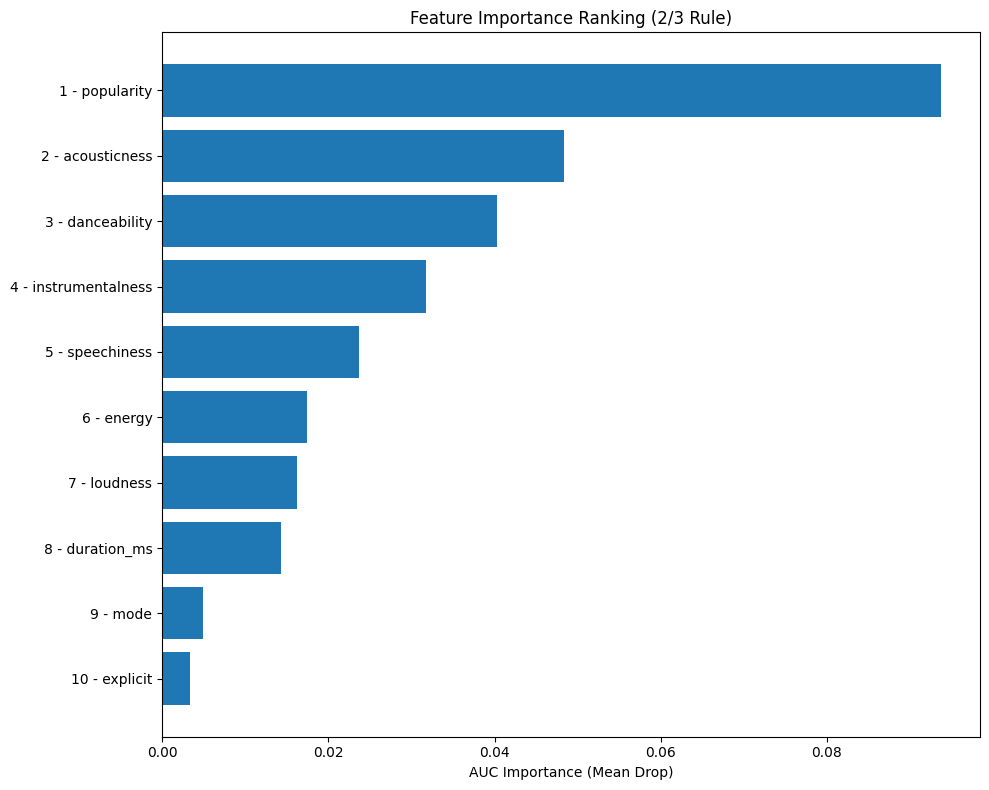


Pipeline Completed Successfully (2/3 Rule)


In [ ]:
# ============================================
# XGBoost + AUC-based Permutation Importance
# Dynamic 2/3 Feature Selection Rule
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder # Re-added for multi-class target encoding

from xgboost import XGBClassifier


# ============================================
# 1. Load Dataset
# ============================================

data = pd.read_csv('https://raw.githubusercontent.com/qpitawat/CS372_MiniProject/refs/heads/main/Spotify_Tracks_Dataset.csv')
target_genres = [
    'pop', 'rock', 'hip-hop', 'classical', 'jazz',
    'electronic', 'metal', 'reggae', 'country', 'blues'
]
data = data[data['track_genre'].isin(target_genres)]

# Define target column and columns to drop for feature matrix
target_column = 'track_genre'
columns_to_drop = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']

# Separate features (X) and target (y)
y = data[target_column]
X = data.drop(columns=[target_column] + columns_to_drop)

# Encode target labels to numerical values for XGBoost
le = LabelEncoder()
y = le.fit_transform(y)

print("======================================")
print("Dataset Loaded")
print("Samples:", X.shape[0])
print("Total Features:", X.shape[1])
print("======================================")


# ============================================
# 2. Train / Validation Split
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ============================================
# 3. Train Initial XGBoost Model
# ============================================

model_full = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss", # Changed eval_metric for multi-class classification
    n_jobs=-1
)

model_full.fit(X_train, y_train)

baseline_auc = roc_auc_score(
    y_val,
    model_full.predict_proba(X_val),
    multi_class='ovr',
    average='weighted'
)

print("\nBaseline AUC (All Features):", round(baseline_auc, 4))


# ============================================
# 4. Tree-based Ranking (GAIN)
# ============================================

booster = model_full.get_booster()
score_dict = booster.get_score(importance_type="gain")

tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": [score_dict.get(f, 0) for f in X.columns]
}).sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


# ============================================
# 5. Dynamic 2/3 Feature Selection
# ============================================

total_features = X.shape[1]
k = int(np.ceil((2/3) * total_features))

selected_features = tree_importance.head(k)["feature"].tolist()

print(f"\nUsing 2/3 Rule → Selecting top {k} features out of {total_features}")


# ============================================
# 6. Retrain Model with Selected Features
# ============================================

model_selected = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss", # Changed eval_metric for multi-class classification
    n_jobs=-1
)

model_selected.fit(X_train[selected_features], y_train)

selected_auc = roc_auc_score(
    y_val,
    model_selected.predict_proba(X_val[selected_features]),
    multi_class='ovr',
    average='weighted'
)

print("AUC after retraining (2/3 features):", round(selected_auc, 4))


# ============================================
# 7. AUC-Based Permutation Importance
# ============================================

perm = permutation_importance(
    model_selected,
    X_val[selected_features],
    y_val,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc_ovr_weighted", # Changed scoring for multi-class AUC
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "auc_importance_mean": perm.importances_mean,
    "auc_importance_std": perm.importances_std
}).sort_values(
    by="auc_importance_mean",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1

importance_df = importance_df[[
    "rank",
    "feature",
    "auc_importance_mean",
    "auc_importance_std"
]]


# ============================================
# 8. Display Ranking
# ============================================

print("\n======================================")
print("AUC-Based Permutation Importance Ranking")
print("======================================")
print(importance_df)
print("\n\n")

# ============================================
# 9. Plot Importance
# ============================================

plt.figure(figsize=(10, 8))

labels = importance_df["rank"].astype(str) + " - " + importance_df["feature"]

plt.barh(labels, importance_df["auc_importance_mean"])
plt.xlabel("AUC Importance (Mean Drop)")
plt.title("Feature Importance Ranking (2/3 Rule)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPipeline Completed Successfully (2/3 Rule)")